# Test Victor


In [1]:
data_path = "../data/datasets/VICTOR/train_small.csv"


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(data_path)
df.head()

,themes,process_id,file_name,document_type,pages,body
0,[232],AI_856934,AI_856934_1926210_1060_17072013.pdf,outros,1,"{""tribunal justiça estado bahia poder judiciár..."
1,[232],AI_856934,AI_856934_1926211_34_17072013.pdf,outros,1,"{""excelentíssimo senhor doutor juiz direito ju..."
2,[232],AI_856934,AI_856934_1926211_34_17072013.pdf,outros,2,"{""razões recurso inominado recorrente atlantic..."
3,[232],AI_856934,AI_856934_1926211_34_17072013.pdf,outros,3,"{""empresa recorrente tornou credora dos débito..."
4,[232],AI_856934,AI_856934_1926211_34_17072013.pdf,outros,4,"{""entretanto verdade parte apelante tornou tit..."


In [5]:
document_types = list(set(df["document_type"]))
document_types

['peticao_do_RE',
 'despacho_de_admissibilidade',
 'outros',
 'agravo_em_recurso_extraordinario',
 'sentenca',
 'acordao_de_2_instancia']

# EURLEX


In [6]:
from datasets import load_dataset
dataset = load_dataset('multi_eurlex', 'pt')

README.md: 0.00B [00:00, ?B/s]

multi_eurlex.py: 0.00B [00:00, ?B/s]

multi_eurlex.tar.gz:   0%|          | 0.00/2.77G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/55000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [7]:
dataset.column_names

{'train': ['celex_id', 'text', 'labels'],
 'test': ['celex_id', 'text', 'labels'],
 'validation': ['celex_id', 'text', 'labels']}

DatasetDict({
    train: Dataset({
        features: ['celex_id', 'text', 'labels'],
        num_rows: 52370
    })
    test: Dataset({
        features: ['celex_id', 'text', 'labels'],
        num_rows: 5000
    })
    validation: Dataset({
        features: ['celex_id', 'text', 'labels'],
        num_rows: 5000
    })
})
{'celex_id': '32006D0213', 'text': 'DECISÃO DA COMISSÃO\nde 6 de Março de 2006\nque estabelece as classes de desempenho em matéria de reacção ao fogo no que respeita a certos produtos de construção, nomeadamente pavimentos de madeira e painéis e revestimentos de madeira maciça\n[notificada com o número C(2006) 655]\n(Texto relevante para efeitos do EEE)\n(2006/213/CE)\nA COMISSÃO DAS COMUNIDADES EUROPEIAS,\nTendo em conta o Tratado que institui a Comunidade Europeia,\nTendo em conta a Directiva 89/106/CEE do Conselho, de 21 de Dezembro de 1988, relativa à aproximação das disposições legislativas, regulamentares e administrativas dos Estados-Membros no que respeita ao

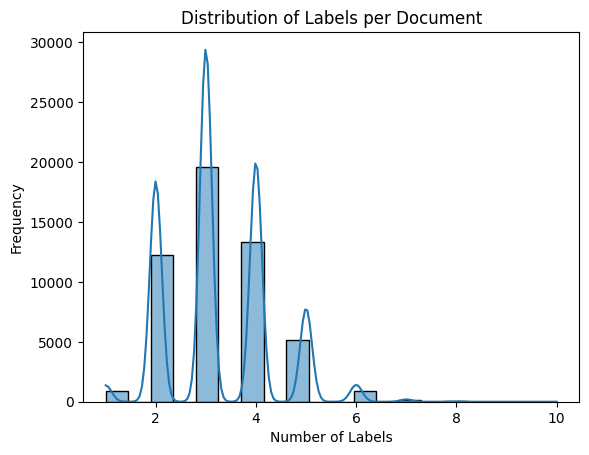

count     52370.000000
mean       1220.626103
std        2885.711949
min          95.000000
25%         353.000000
50%         494.000000
75%         937.000000
max      140935.000000
Name: doc_length, dtype: float64


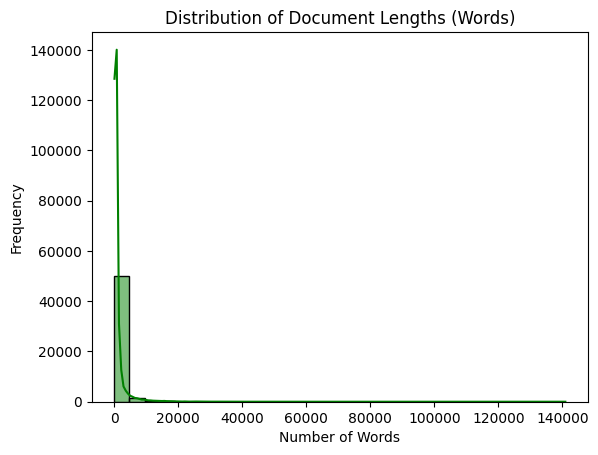

3     28786
17    26076
18    21803
6     18764
15    13146
2      8513
5      8188
19     6673
0      5852
1      5376
4      4859
7      4035
12     3521
8      3254
20     3032
11     2179
10     2048
9      1881
14     1044
16      636
Name: count, dtype: int64


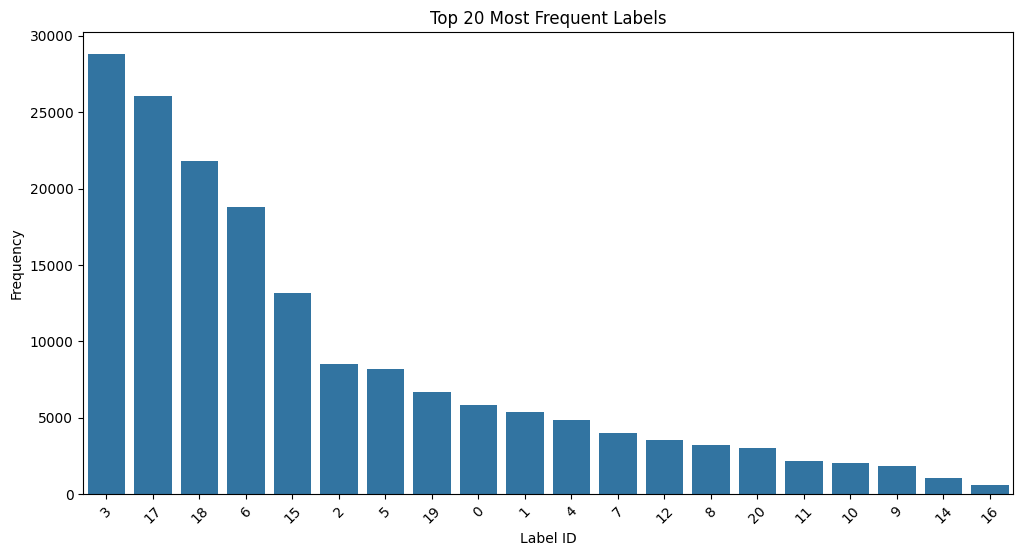

In [9]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the dataset
dataset = load_dataset('multi_eurlex', 'pt')

# Explore the dataset structure
print(dataset)

# Check a few examples
print(dataset['train'][0])

# Create a DataFrame for easier manipulation
data = dataset['train'].to_pandas()

# Basic info
print(data.head())
print(data.info())

# Number of labels per document
data['num_labels'] = data['labels'].apply(len)
print(data['num_labels'].describe())

# Plot distribution of number of labels per document
sns.histplot(data['num_labels'], bins=20, kde=True)
plt.title("Distribution of Labels per Document")
plt.xlabel("Number of Labels")
plt.ylabel("Frequency")
plt.show()

# Document length (in tokens or characters)
data['doc_length'] = data['text'].apply(lambda x: len(x.split()))
print(data['doc_length'].describe())

# Plot distribution of document lengths
sns.histplot(data['doc_length'], bins=30, kde=True, color='green')
plt.title("Distribution of Document Lengths (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Frequency of individual labels
all_labels = [label for sublist in data['labels'] for label in sublist]

# Count label frequencies
label_counts = pd.Series(all_labels).value_counts()

# Display top 20 most frequent labels
print(label_counts.head(20))

# Barplot of top 20 labels
plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.head(20).index.astype(str), y=label_counts.head(20).values)
plt.title("Top 20 Most Frequent Labels")
plt.xlabel("Label ID")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


# Alagoas

https://github.com/lagefreitas/predicting-brazilian-court-decisions

In [18]:
data = pd.read_csv("../data/datasets/VICTOR/dataset.csv", sep="<=>", engine="python", dayfirst=True)

In [19]:

print('data.shape=' + str(data.shape) + ' full data set')
# Removing NA values
data = data.dropna(subset=[data.columns[9]])# decision_description
data = data.dropna(subset=[data.columns[11]])# decision_label
print('data.shape=' + str(data.shape) + ' dropna')
# Removing duplicated samples
# df = data.groupby(['process_number']).size().reset_index(name='count')
# print('df.shape=' + str(df.shape) + ' removed duplicated samples by process number')
data = data.drop_duplicates(subset=[data.columns[1]]) # process_number
print('data.shape=' + str(data.shape) + ' removed duplicated samples by process_number')
data = data.drop_duplicates(subset=[data.columns[9]]) # decision_description
print('data.shape=' + str(data.shape) + ' removed duplicated samples by decision_description')
# Removing not relevant decision labels and decision not properly labeled
data = data.query('decision_label != "conflito-competencia"')
print('data.shape=' + str(data.shape) + ' removed decisions labeled as conflito-competencia')
data = data.query('decision_label != "prejudicada"')
print('data.shape=' + str(data.shape) + ' removed decisions labeled as prejudicada')
data = data.query('decision_label != "not-cognized"')
print('data.shape=' + str(data.shape) + ' removed decisions labeled as not-cognized')
data_no = data.query('decision_label == "no"')
print('data_no.shape=' + str(data_no.shape))
data_yes = data.query('decision_label == "yes"')
print('data_yes.shape=' + str(data_yes.shape))
data_partial = data.query('decision_label == "partial"')
print('data_partial.shape=' + str(data_partial.shape))
# Merging decisions whose labels are yes, no, and partial to build the final data set
data_merged = data_no.merge(data_yes, how='outer')
data = data_merged.merge(data_partial, how='outer')
print('data.shape=' + str(data.shape) + ' merged decisions whose labels are yes, no, and partial')
# Removing decision_description and decision_labels whose values are -1 and -2
indexNames = data[ (data['decision_description'] == str(-1)) |                    (data['decision_description'] == str(-2)) |                    (data['decision_label'] == str(-1)) |                    (data['decision_label'] == str(-2)) ].index
# print('indexNames='+str(len(indexNames)))
data.drop(indexNames, inplace=True)
print('data.shape=' + str(data.shape) + ' removed -1 and -2 decision descriptions and labels')



data.shape=(9644, 14) full data set
data.shape=(9608, 14) dropna
data.shape=(4762, 14) removed duplicated samples by process_number
data.shape=(4332, 14) removed duplicated samples by decision_description
data.shape=(4299, 14) removed decisions labeled as conflito-competencia
data.shape=(4122, 14) removed decisions labeled as prejudicada
data.shape=(4043, 14) removed decisions labeled as not-cognized
data_no.shape=(2415, 14)
data_yes.shape=(762, 14)
data_partial.shape=(866, 14)
data.shape=(4043, 14) merged decisions whose labels are yes, no, and partial
data.shape=(4043, 14) removed -1 and -2 decision descriptions and labels


In [20]:
data.columns

Index(['ementa_filepath', 'process_number', 'process_type', 'orgao_julgador',
       'publish_date', 'judgment_date', 'judge_relator', 'ementa_text',
       'decisions', 'decision_description', 'decision_text', 'decision_label',
       'decision_unanimity_text', 'decision_unanimity'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4043 entries, 0 to 4042
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ementa_filepath          4043 non-null   object 
 1   process_number           4042 non-null   object 
 2   process_type             4043 non-null   object 
 3   orgao_julgador           4043 non-null   object 
 4   publish_date             4043 non-null   object 
 5   judgment_date            4043 non-null   object 
 6   judge_relator            4043 non-null   object 
 7   ementa_text              4043 non-null   object 
 8   decisions                0 non-null      float64
 9   decision_description     4043 non-null   object 
 10  decision_text            4043 non-null   object 
 11  decision_label           4043 non-null   object 
 12  decision_unanimity_text  4043 non-null   object 
 13  decision_unanimity       4043 non-null   object 
dtypes: float64(1), object(13

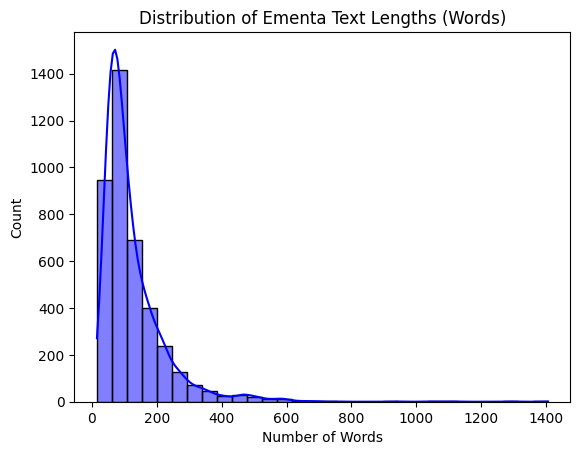

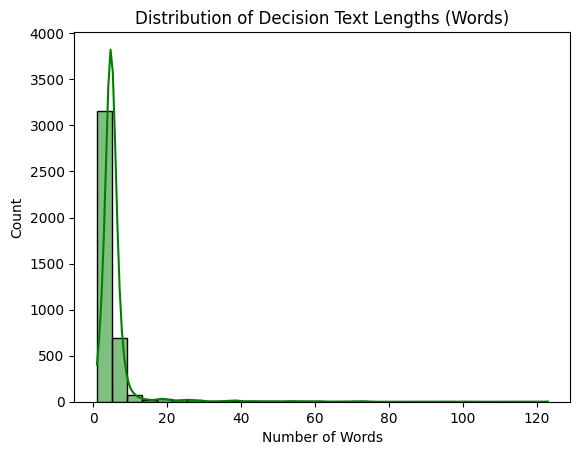


Date Range:
Publish Dates: 2018-12-14 00:00:00 to 2019-04-03 00:00:00
Judgment Dates: NaT to NaT

Unanimity Rate per Decision Label:
decision_unanimity        -2       -2"  not-unanimity  not-unanimity"  \
decision_label                                                          
no                  0.121325  0.360663       0.000414        0.005383   
partial             0.107390  0.342956       0.000000        0.009238   
yes                 0.173228  0.297900       0.001312        0.027559   

decision_unanimity  unanimity  unanimity"  
decision_label                             
no                   0.126294    0.385921  
partial              0.073903    0.466513  
yes                  0.097113    0.402887  


/tmp/ipykernel_20384/3890606426.py:43: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['publish_date'] = pd.to_datetime(data['publish_date'], errors='coerce')


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is called 'df'

# General overview
print(data.info())
print(data.head())

# Missing values
print(data.isnull().sum())

# Unique counts for key categorical columns
print("\nUnique Process Types:", data['process_type'].nunique())
print(data['process_type'].value_counts())

print("\nUnique Judging Bodies (orgao_julgador):", data['orgao_julgador'].nunique())
print(data['orgao_julgador'].value_counts().head(10))

print("\nUnique Decision Labels:", data['decision_label'].nunique())
print(data['decision_label'].value_counts())

print("\nUnanimity Distribution:")
print(data['decision_unanimity'].value_counts())

# Text length analysis
data['ementa_length'] = data['ementa_text'].astype(str).apply(lambda x: len(x.split()))
data['decision_length'] = data['decision_text'].astype(str).apply(lambda x: len(x.split()))

# Plot distributions
sns.histplot(data['ementa_length'], bins=30, kde=True, color='blue')
plt.title("Distribution of Ementa Text Lengths (Words)")
plt.xlabel("Number of Words")
plt.show()

sns.histplot(data['decision_length'], bins=30, kde=True, color='green')
plt.title("Distribution of Decision Text Lengths (Words)")
plt.xlabel("Number of Words")
plt.show()

# Date conversion and range checking
data['publish_date'] = pd.to_datetime(data['publish_date'], errors='coerce')
data['judgment_date'] = pd.to_datetime(data['judgment_date'], errors='coerce')

print("\nDate Range:")
print(f"Publish Dates: {data['publish_date'].min()} to {data['publish_date'].max()}")
print(f"Judgment Dates: {data['judgment_date'].min()} to {data['judgment_date'].max()}")

# Unanimity breakdown with labels
unanimity_summary = data.groupby('decision_label')['decision_unanimity'].value_counts(normalize=True).unstack().fillna(0)
print("\nUnanimity Rate per Decision Label:")
print(unanimity_summary)
